9
[[1 2 0 1 1 0 1 1]]
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 18
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 18
Setting n_reactions to maximum value: 18
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 18
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 18
Setting n_reactions to maximum value: 16
Setting n_reactions to maximum value: 16


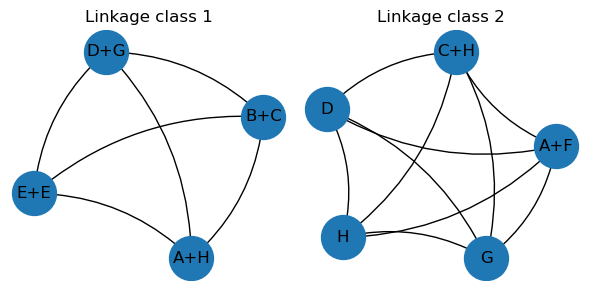

In [64]:
from ConservationLaws import *
import matplotlib.pyplot as plt
import sympy
import networkx as nx

from scipy.integrate import solve_ivp
from functools import partial
import time

seed = 1
np.random.seed(seed)
random.seed(seed)

# n_species = 7
# n_complexes = 9
# n_reactions = 10
# force_reverse = True
# n_cons = 1
# n_lcs = n_complexes - n_species + n_cons

# n_species = 10
# n_complexes = 13
# n_reactions = 15
# force_reverse = True
# n_cons = 1
# n_lcs = n_complexes - n_species + n_cons

n_species = 8
n_lcs = 2
n_reactions = 30
force_reverse = True
n_cons = 1
n_complexes = n_lcs + n_species - n_cons
print(n_complexes)



probs = np.array([2, 10, 6])
probs = probs / sum(probs)
L = random_conservation_laws(n_cons, n_species, probs)
print(L)

# Build the reaction network
r_n = ReactionNetwork(
    n_complexes, n_reactions, n_lcs, n_species, L, n_cons, seed, force_reverse=force_reverse
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)
sim.solve_conservation_laws()
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])

(dR_dC, dR_dC_func, 
 dR_dl, dR_dl_func, 
 dR_dk, dR_dk_func,
 dR_dC_dk, dR_dC_dk_func, dR_dl_dk, dR_dl_dk_func,
 remaining_syms) = sim.get_derivatives()

sz = 3
fig, axes = plt.subplots(1, len(r_n.linkage_groups), figsize=(sz*len(r_n.linkage_groups), sz))

if len(r_n.linkage_groups) == 1:
    pos = nx.spring_layout(r_n.linkage_groups[0])
    nx.draw(r_n.linkage_groups[0], pos=pos, with_labels=True, ax=axes, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
    axes.set_title("Linkage class 1")
else:
    for i, (G, ax) in enumerate(zip(r_n.linkage_groups, axes)):
        pos = nx.spring_layout(G)
        nx.draw(G, pos=pos, with_labels=True, ax=ax, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
        ax.set_title(f"Linkage class {i+1}")
plt.tight_layout()
plt.show()

In [65]:
############################################################
################  Load classification data #################
############################################################

n_classes = 2
######  Gaussian example
n_samples = 20000
input_dim = 1

mu_1 = 1e2 * np.ones(input_dim)
cov_1 = 1.0 * np.diag(np.ones(input_dim))
dist_1 = np.abs(np.random.multivariate_normal(mu_1, cov_1, n_samples))

mu_2 = 5e0 * np.ones(input_dim)
cov_2 = 1.0 * np.diag(np.ones(input_dim))
dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

input_data = InputData(n_classes, data_list)




In [70]:
#rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])
rates = np.array(rates_orig.copy())
log_rates = np.log(rates)
r_n.update_rates(rates)
n_rates = len(rates)

t_span = (0, 100000)
num_points = 2000  
r_tol = 1e-3    
a_tol = 1e-3

eta = 2.5e0

class_ids = [1, 3]
# class_ids = [7, 1]
l_ind = 0

loss_list = [[] for _ in range(len(class_ids))]
start_time = time.time()
batch_size = 5
num_batches = 500 // batch_size  # total number of batches

for batch in range(num_batches):
    grad_accum = 0.0  # or np.zeros_like(rates) if grad is an array
    for _ in range(batch_size):
        class_number = random.randrange(n_classes)
        inputs = input_data.get_next_training_sample(class_number)
        l0 = np.array(inputs)

        C_full = generate_positive_initial_concentrations_nnls(L, l0)
        _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
        sim.make_reduced_rhs_with_conservation(l0)

        sol_reduced, C_reduced_final = sim.integrate(
            sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
        )

        C_full = sim.recover_eliminated_species(l0, C_reduced_final)
        dC_dk = sim.dC_dk_func(C_reduced_final, l0, rates, dR_dC_func, dR_dk_func)
        dC_dk_full = sim.compute_dC_dk_full(dC_dk)

        probs = compute_probs(C_full, L[l_ind], l0[l_ind])
        dprobs_dk_full = compute_probs(dC_dk_full, L[l_ind], l0[l_ind])

        loss = (probs[class_ids[class_number]] - 1.0)
        grad = dprobs_dk_full[class_ids[class_number]] * loss
        grad_accum += grad
        loss_list[class_number].append(loss**2)

    grad_accum /= batch_size  # average the gradients
    #rates = np.clip(rates - eta * grad_accum, 0, 100000)
    log_rates = log_rates - eta * grad_accum * rates  # chain rule
    rates = np.exp(log_rates)
    r_n.update_rates(rates)

end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")


Time taken: 13.79000997543335 seconds


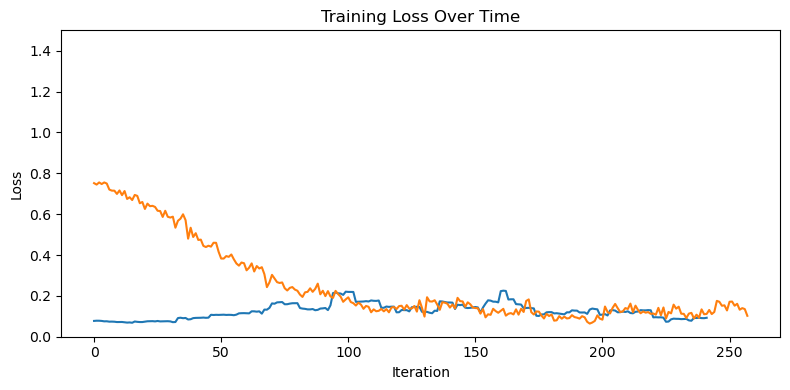

In [71]:
plt.figure(figsize=(8, 4))
plt.plot(loss_list[0])
plt.plot(loss_list[1])
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.ylim(0, 1.5)
plt.title('Training Loss Over Time')
plt.tight_layout()
plt.show()

In [54]:
n_l0 = 20
l0_space = np.logspace(0, 2.5, n_l0)
prob_array = np.zeros((n_species, n_l0))

t_span = (0, 10000)
num_points = 2000  
r_tol = 1e-2  
a_tol = 1e-2

r_n.update_rates(rates)
#_, _, _ = sim.get_symbolic_rhs()
for (i, l0) in enumerate(l0_space):
    l0 = [l0]
    C_full = generate_positive_initial_concentrations_nnls(L, l0, min_conc=1e-4)
    sol_full, C_full = sim.integrate(sim.rhs, C_full, t_span=t_span, num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol)
    probs = compute_probs(C_full, L[l_ind], l0[l_ind])
    prob_array[:,i] = probs


    

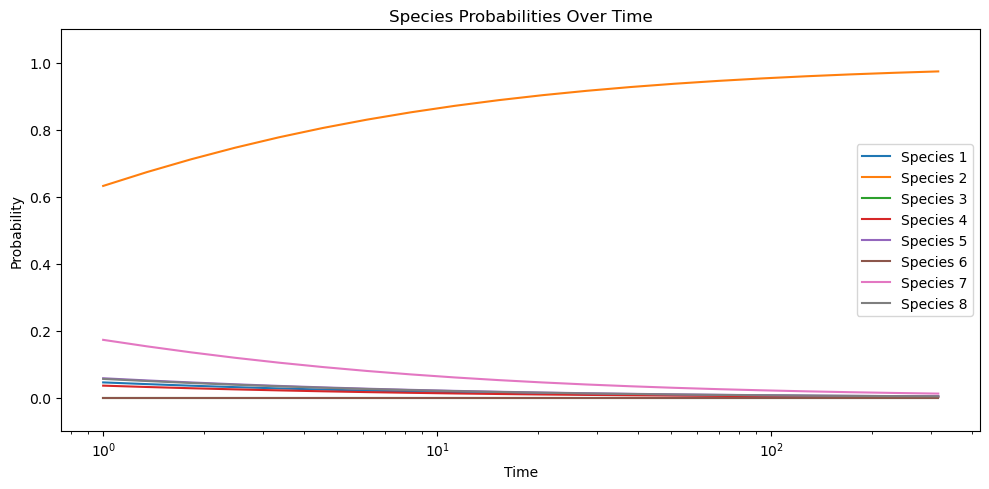

In [55]:
plt.figure(figsize=(10, 5))
for i in range(prob_array.shape[0]):
    plt.plot(l0_space, prob_array[i,:], label=f'Species {i+1}')
plt.xlabel('Time')
plt.ylabel('Probability')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.title('Species Probabilities Over Time')
plt.xscale('log')
plt.tight_layout()
plt.show()

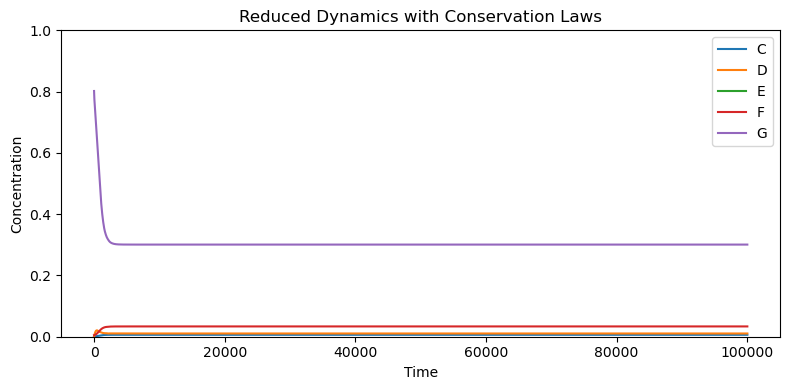

In [27]:
plt.figure(figsize=(8, 4))
for i, name in enumerate(sim.remaining_species):
    plt.plot(sol_reduced.t, sol_reduced.y[i], label=name)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.ylim(0, 1)
plt.title('Reduced Dynamics with Conservation Laws')
plt.tight_layout()
plt.show()

In [131]:
st_val = 0
l_init = 1e0
l_fin = 1e2
l_base = np.array([l_init])
l_target = np.array([l_fin])
l_norm = np.linalg.norm(l_target)
l_unit_vec = l_target / l_norm

# 4. Integrate the reduced system

C_full = generate_positive_initial_concentrations_nnls(L, l_base)
t_span = (0, 10000)
num_points = 200000  
r_tol = 1e-6
a_tol = 1e-6
sol_full, C_full_init = sim.integrate(sim.rhs, C_full, t_span=t_span, num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol)
const_vals, C0_reduced_initial = sim.get_const_and_reduced_init(C_full_init)

def ode_func(t, C):
    return sim.dC_func(
        t, C,
        rates,
        l_target/l_norm,
        l_base,
        dR_dC_func,
        dR_dl_func
    )

l_target = np.array([l_fin])
l_norm = np.linalg.norm(l_target)
l_unit_vec = l_target / l_norm

sol = solve_ivp(
    ode_func,
    t_span=(st_val, l_norm),
    y0=C0_reduced_initial,
    method='LSODA',  # or 'LSODA'
    rtol=r_tol,
    atol=a_tol
)   


